In [2]:
import pandas as pd
import numpy as np
import shapely as shp
import sqlite3, imageio, pickle, os, zlib, base64
from pygifsicle import optimize
import matplotlib.pyplot as plt
import moviepy.editor as mp
from stats import SingleRun, MAPS, plot_map, get_map_img

path = '../data/data_test.db'

start execution 106
/home/aislab/Documents/Tellaroli/test_ws/src/journal_rendezvous/stats/figures/gif/ex106
Moviepy - Building video figures/gif/ex106.mp4.
Moviepy - Writing video figures/gif/ex106.mp4



Moviepy - Done !
Moviepy - video ready figures/gif/ex106.mp4


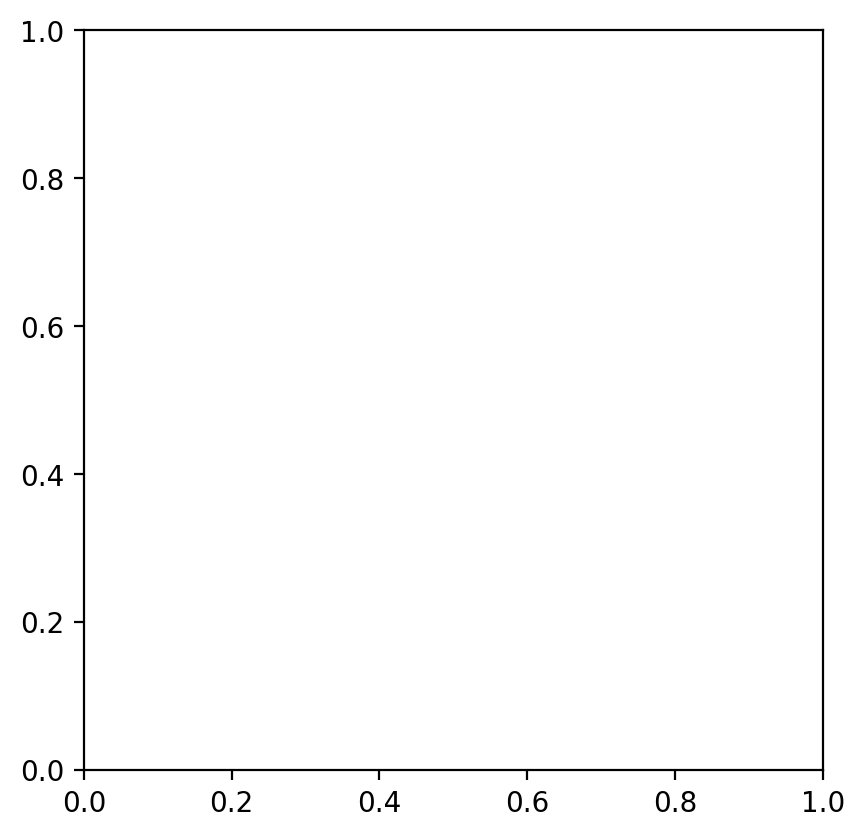

In [13]:
for ex in [106]: #[452,453,462,463,464,465]:
    print("start execution "+ str(ex))
    execution = ex

    SR = SingleRun(path, ex)

    fig, ax = plt.subplots(dpi=200)
    x = MAPS['office_2'] #  'office_big', 'office_2', 'map23', 'e13','e40','13-3

    start_time = SR.get_start_time()+2
    frame = 15
    output_path = "figures/gif/ex" + str(execution)
    output_path = output_path.replace(" ", "\\ ")
    print(os.getcwd()+"/"+output_path)
    os.makedirs(os.getcwd()+"/"+output_path, exist_ok=True)
    i=0
    rendez_time = SR.get_rendezvous_time()
    time_iter = np.arange(
        start_time,
        start_time+rendez_time if rendez_time else SR.get_last_time(),
        frame
    )
    imgcounter = 0
    for t in time_iter:
        imgcounter+=1
        plot_map(
            get_map_img(x),
            ax
        )
        SR.plot_tracciato(ax=ax, map=x, time=t)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(round(t,2))
        plt.savefig(f'{output_path}/fig{i+1}.png', bbox_inches = "tight")
        ax.set_aspect('equal')
        i+=1
        ax.clear()
        if imgcounter > 500 :
            break

    images = []
    for j in range(len(time_iter)):
        images.append(imageio.imread(f"{output_path}/fig{j+1}.png"))
    imageio.mimsave(f'figures/gif/ex{execution}.gif', images, duration=250)
    optimize(f'figures/gif/ex{execution}.gif', f'figures/gif/ex{execution}.gif')

    clip = mp.VideoFileClip(f'figures/gif/ex{execution}.gif')
    clip.write_videofile(f'figures/gif/ex{execution}.mp4')